In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Valores de las variables
Nind = 5
Lind = 10
Pc = 0.70
Pm = 1 / 15
Maxgen = 100
rango = [0, 0.875]

In [2]:
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))

In [3]:
def decodifica(genotipo, rango, Lind):
    Nind = genotipo.shape[0]
    fenotipo = np.zeros(Nind)
    max_val = 2**Lind - 1
    for i in range(Nind):
        entero = int("".join(map(str, genotipo[i].astype(int))), 2)
        fenotipo[i] = rango[0] + (rango[1] - rango[0]) * entero / max_val
    return fenotipo

In [4]:
def objfun(fenotipo):
    u = (11 / 2) * fenotipo - (7 / 2)
    return 1 - u**2 * np.cos(u) + 1 + 2


In [5]:
def rankeo(objv, direccion):
    SP = 2
    Nind = len(objv)
    aptitud = np.zeros(Nind)
 
    if direccion == 1:
        nuevo_objv = np.sort(objv)
    else:
        nuevo_objv = np.sort(-1 * objv)
 
    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv)
 
    aptitud[posori] = apt
 
    return aptitud

In [6]:
def ruleta(genotipo, aptitud):
    Nind = len(aptitud)
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros(Nind, dtype=int)
 
    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i] = aux[0]
 
    nuevo_gen = genotipo[idx, :]
 
    return nuevo_gen
 

In [7]:
def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = nuevo_gen.copy()
    par = Nind % 2
 
    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(1, Lind)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
 
    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]
 
    nuevo_gen = aux_gen
 
    return nuevo_gen


In [8]:
def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    for i in range(Nind):
        for j in range(Lind):
            if np.random.rand() <= Pm:
                nuevo_gen[i, j] = 1 - nuevo_gen[i, j]
    return nuevo_gen

In [9]:
#crear población inicial
np.random.seed(42)
genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango, Lind)
generaciones = 1

In [10]:

Mejor = np.full(Maxgen, np.nan)
Mejor_x = np.full(Maxgen, np.nan)
objv = objfun(fenotipo)

In [11]:

generaciones = 1
 
while generaciones < Maxgen:
 
    # Selección proporcional (ruleta)
    aptitud = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, aptitud)
 
    # Cruza desde un punto
    nuevo_gen = xunpunto(nuevo_gen, Pc)
 
    # Mutación aleatoria
    nuevo_gen = muta(nuevo_gen, Pm)
 
    # Decodificar y evaluar la nueva población
    nuevo_feno = decodifica(nuevo_gen, rango, Lind)
    nuevo_objv = objfun(nuevo_feno)
 
    # Sustituir la población anterior
    genotipo = nuevo_gen
    objv = nuevo_objv
 
    # Almacenar la mejor solución de la generación
    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_x[generaciones] = decodifica(genotipo[idx:idx+1], rango, Lind)[0]
 
    generaciones += 1
 

In [12]:
mejor_idx = np.nanargmax(Mejor)
mejor_valor = Mejor[mejor_idx]
mejor_x = Mejor_x[mejor_idx]
 
print("RESULTADO DEL ALGORITMO GENÉTICO")
print(f"Mejor valor encontrado: {mejor_valor:.4f}")
print(f"x = {mejor_x:.4f}")
print(f"Generación: {mejor_idx}")

RESULTADO DEL ALGORITMO GENÉTICO
Mejor valor encontrado: 15.4266
x = 0.0034
Generación: 13


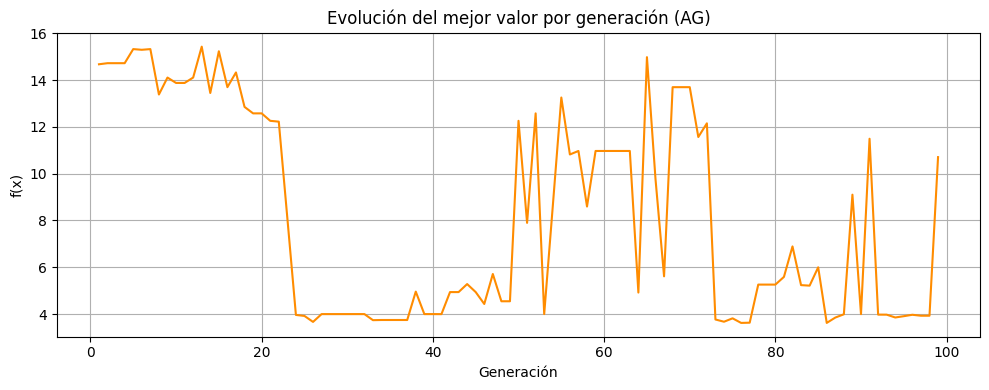

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(Mejor, color='darkorange', linewidth=1.5)
plt.xlabel('Generación')
plt.ylabel('f(x)')
plt.title('Evolución del mejor valor por generación (AG)')
plt.grid(True)
plt.tight_layout()
plt.show()
 

In [14]:
def f(x):
    u = (11 / 2) * x - (7 / 2)
    return 1 - u**2 * np.cos(u) + 1 + 2
 
x = np.linspace(0, 0.875, 500)
y = f(x)

RESULTADO SIN AG (búsqueda exhaustiva)
Mejor valor encontrado: 15.4716
x = 0.0000


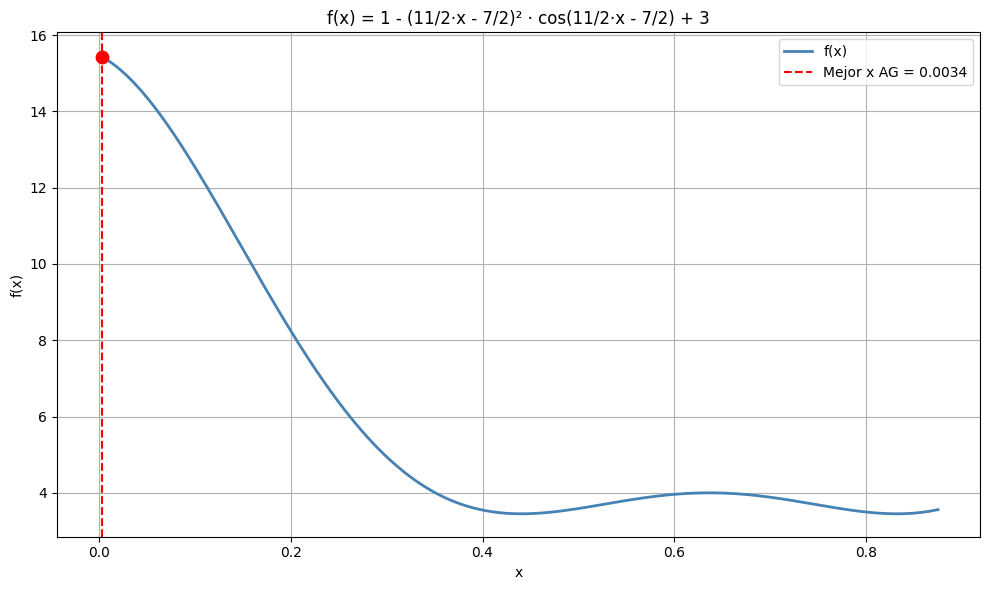

In [15]:

 
# Máximo real de la función (búsqueda exhaustiva)
max_idx = np.argmax(y)
print("RESULTADO SIN AG (búsqueda exhaustiva)")
print(f"Mejor valor encontrado: {y[max_idx]:.4f}")
print(f"x = {x[max_idx]:.4f}")
 
# Gráfica
fig = plt.figure(figsize=(10, 6))
plt.plot(x, y, color='steelblue', linewidth=2, label='f(x)')
plt.axvline(mejor_x, color='red', linestyle='--', linewidth=1.5, label=f'Mejor x AG = {mejor_x:.4f}')
plt.scatter([mejor_x], [mejor_valor], color='red', zorder=5, s=80)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('f(x) = 1 - (11/2·x - 7/2)² · cos(11/2·x - 7/2) + 3')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()